In [ ]:
import zipfile
zip_ref = zipfile.ZipFile('/content/Data (1) (1).zip','r')


zip_ref.extractall('/content')
zip_ref.close()

In [ ]:
import pandas as pd
df=pd.read_csv('/content/RawData/2012-2013 Solar home electricity data v2.csv')
df.head()

/tmp/ipykernel_756/1636176525.py:2: DtypeWarning: Columns (0,1,2,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('/content/RawData/2012-2013 Solar home electricity data v2.csv')


,"2012-2013 Solar home electricity data - Before using this data, please read the attached pdf document ""Ausgrid solar home electricity data notes (Aug 2014).pdf""",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51,Unnamed: 52,Unnamed: 53
0,Customer,Generator Capacity,Postcode,Consumption Category,date,0:30,1:00,1:30,2:00,2:30,...,20:00,20:30,21:00,21:30,22:00,22:30,23:00,23:30,0:00,Row Quality
1,1,3.78,2076,CL,1/07/2012,1.25,1.25,1.25,1.263,0.131,...,0,0,0,0,0,0,0,0,1.081,NaN
2,1,3.78,2076,GC,1/07/2012,0.855,0.786,0.604,0.544,0.597,...,0.374,0.447,0.549,0.136,0.288,0.181,0.651,0.09,0.068,NaN
3,1,3.78,2076,GG,1/07/2012,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,NaN
4,1,3.78,2076,CL,2/07/2012,1.25,1.25,1.125,0,0.925,...,0,0,0,0,0,0,0,0,1.069,NaN


In [ ]:
# Reload the raw dataset
df = pd.read_csv(
    '/content/RawData/2012-2013 Solar home electricity data v2.csv',
    header=1
)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Shape: (268557, 54)

Columns:
['Customer', 'Generator Capacity', 'Postcode', 'Consumption Category', 'date', '0:30', '1:00', '1:30', '2:00', '2:30', '3:00', '3:30', '4:00', '4:30', '5:00', '5:30', '6:00', '6:30', '7:00', '7:30', '8:00', '8:30', '9:00', '9:30', '10:00', '10:30', '11:00', '11:30', '12:00', '12:30', '13:00', '13:30', '14:00', '14:30', '15:00', '15:30', '16:00', '16:30', '17:00', '17:30', '18:00', '18:30', '19:00', '19:30', '20:00', '20:30', '21:00', '21:30', '22:00', '22:30', '23:00', '23:30', '0:00', 'Row Quality']

First 5 rows:


,Customer,Generator Capacity,Postcode,Consumption Category,date,0:30,1:00,1:30,2:00,2:30,...,20:00,20:30,21:00,21:30,22:00,22:30,23:00,23:30,0:00,Row Quality
0,1,3.78,2076,CL,1/07/2012,1.250,1.250,1.250,1.263,0.131,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.081,NaN
1,1,3.78,2076,GC,1/07/2012,0.855,0.786,0.604,0.544,0.597,...,0.374,0.447,0.549,0.136,0.288,0.181,0.651,0.090,0.068,NaN
2,1,3.78,2076,GG,1/07/2012,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,NaN
3,1,3.78,2076,CL,2/07/2012,1.250,1.250,1.125,0.000,0.925,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.069,NaN
4,1,3.78,2076,GC,2/07/2012,0.309,0.082,0.059,0.097,0.290,...,0.353,0.464,0.229,0.811,0.222,0.306,1.034,0.136,0.067,NaN


In [ ]:
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nConsumption Categories:")
print(df["Consumption Category"].value_counts(dropna=False))


Data types:
Customer                  int64
Generator Capacity      float64
Postcode                  int64
Consumption Category     object
date                     object
0:30                    float64
1:00                    float64
1:30                    float64
2:00                    float64
2:30                    float64
3:00                    float64
3:30                    float64
4:00                    float64
4:30                    float64
5:00                    float64
5:30                    float64
6:00                    float64
6:30                    float64
7:00                    float64
7:30                    float64
8:00                    float64
8:30                    float64
9:00                    float64
9:30                    float64
10:00                   float64
10:30                   float64
11:00                   float64
11:30                   float64
12:00                   float64
12:30                   float64
13:00                   flo

In [ ]:
print("===== CUSTOMER VALIDATION =====")

print("Number of unique customers:")
print(df["Customer"].nunique())

print("\nCustomer ID range:")
print(df["Customer"].min(), "to", df["Customer"].max())

print("\nMissing customer IDs:")
expected_customers = set(range(1, 301))
actual_customers = set(df["Customer"].unique())
print(sorted(expected_customers - actual_customers))

print("\n===== GENERATOR CAPACITY =====")

print("Unique generator capacities:")
print(df["Generator Capacity"].nunique())

print("\nGenerator capacity range:")
print(
    df["Generator Capacity"].min(),
    "to",
    df["Generator Capacity"].max()
)

print("\n===== POSTCODE =====")

print("Unique postcodes:")
print(df["Postcode"].nunique())

print("\n===== DATE =====")

df["date"] = pd.to_datetime(
    df["date"],
    dayfirst=True
)

print("Date range:")
print(df["date"].min(), "to", df["date"].max())

print("\nNumber of unique dates:")
print(df["date"].nunique())

print("\n===== CATEGORY × CUSTOMER =====")

print(
    df.groupby("Consumption Category")["Customer"]
      .nunique()
)

print("\n===== ROWS PER CATEGORY =====")

print(
    df["Consumption Category"]
      .value_counts()
)

===== CUSTOMER VALIDATION =====
Number of unique customers:
300

Customer ID range:
1 to 300

Missing customer IDs:
[]

===== GENERATOR CAPACITY =====
Unique generator capacities:
62

Generator capacity range:
1.0 to 9.99

===== POSTCODE =====
Unique postcodes:
100

===== DATE =====
Date range:
2012-07-01 00:00:00 to 2013-06-30 00:00:00

Number of unique dates:
365

===== CATEGORY × CUSTOMER =====
Consumption Category
CL    138
GC    300
GG    300
Name: Customer, dtype: int64

===== ROWS PER CATEGORY =====
Consumption Category
GC    109419
GG    109419
CL     49719
Name: count, dtype: int64


In [ ]:
# Separate load categories
gc_df = df[df["Consumption Category"] == "GC"].copy()
cl_df = df[df["Consumption Category"] == "CL"].copy()

print("GC shape:", gc_df.shape)
print("CL shape:", cl_df.shape)

print("\nGC unique customers:", gc_df["Customer"].nunique())
print("CL unique customers:", cl_df["Customer"].nunique())

print("\nGC date range:")
print(gc_df["date"].min(), "to", gc_df["date"].max())

print("\nCL date range:")
print(cl_df["date"].min(), "to", cl_df["date"].max())

print("\nNumber of dates per customer — GC:")
print(
    gc_df.groupby("Customer")["date"]
    .nunique()
    .value_counts()
    .sort_index()
)

print("\nNumber of dates per customer — CL:")
print(
    cl_df.groupby("Customer")["date"]
    .nunique()
    .value_counts()
    .sort_index()
)

GC shape: (109419, 54)
CL shape: (49719, 54)

GC unique customers: 300
CL unique customers: 138

GC date range:
2012-07-01 00:00:00 to 2013-06-30 00:00:00

CL date range:
2012-07-01 00:00:00 to 2013-06-30 00:00:00

Number of dates per customer — GC:
date
284      1
365    299
Name: count, dtype: int64

Number of dates per customer — CL:
date
284      1
300      3
305      1
306      1
307      2
317      1
318      1
320      1
365    127
Name: count, dtype: int64


In [ ]:
print("===== GC INCOMPLETE CUSTOMERS =====")

gc_days = gc_df.groupby("Customer")["date"].nunique()

print(
    gc_days[gc_days < 365]
)

print("\n===== CL INCOMPLETE CUSTOMERS =====")

cl_days = cl_df.groupby("Customer")["date"].nunique()

print(
    cl_days[cl_days < 365].sort_values()
)

print("\n===== CL CUSTOMERS WITH MORE THAN 365 DATES =====")

print(
    cl_days[cl_days > 365].sort_values()
)

===== GC INCOMPLETE CUSTOMERS =====
Customer
2    284
Name: date, dtype: int64

===== CL INCOMPLETE CUSTOMERS =====
Customer
2      284
68     300
272    300
284    300
289    305
161    306
294    307
187    307
293    317
95     318
248    320
Name: date, dtype: int64

===== CL CUSTOMERS WITH MORE THAN 365 DATES =====
Series([], Name: date, dtype: int64)


In [ ]:
print("Customer 2 GC dates:", gc_days.get(2))
print("Customer 2 CL dates:", cl_days.get(2))

print("\nCustomer 2 GC missing dates:")

all_dates = pd.date_range(
    start="2012-07-01",
    end="2013-06-30",
    freq="D"
)

customer2_gc_dates = set(
    gc_df.loc[gc_df["Customer"] == 2, "date"]
)

missing_gc_dates = all_dates[
    ~all_dates.isin(customer2_gc_dates)
]

print(missing_gc_dates)

print("\nNumber missing:", len(missing_gc_dates))

Customer 2 GC dates: 284
Customer 2 CL dates: 284

Customer 2 GC missing dates:
DatetimeIndex(['2012-10-12', '2012-10-13', '2012-10-14', '2012-10-15',
               '2012-10-16', '2012-10-17', '2012-10-18', '2012-10-19',
               '2012-10-20', '2012-10-21', '2012-10-22', '2012-10-23',
               '2012-10-24', '2012-10-25', '2012-10-26', '2012-10-27',
               '2012-10-28', '2012-10-29', '2012-10-30', '2012-10-31',
               '2012-11-01', '2012-11-02', '2012-11-03', '2012-11-04',
               '2012-11-05', '2012-11-06', '2012-11-07', '2012-11-08',
               '2012-11-09', '2012-11-10', '2012-11-11', '2012-11-12',
               '2012-11-13', '2012-11-14', '2012-11-15', '2012-11-16',
               '2012-11-17', '2012-11-18', '2012-11-19', '2012-11-20',
               '2012-11-21', '2012-11-22', '2012-11-23', '2012-11-24',
               '2012-11-25', '2012-11-26', '2012-11-27', '2012-11-28',
               '2012-11-29', '2012-11-30', '2012-12-01', '2012-12-02

In [ ]:
# Remove Customer 2 only for the diagnostic checks
load_df = df[
    df["Consumption Category"].isin(["GC", "CL"]) &
    (df["Customer"] != 2)
].copy()

time_cols = [
    col for col in df.columns
    if col not in [
        "Customer",
        "Generator Capacity",
        "Postcode",
        "Consumption Category",
        "date",
        "Row Quality"
    ]
]

print("Load dataset shape:", load_df.shape)

# --------------------------------------------------
# 1. Negative values
# --------------------------------------------------

negative_count = (load_df[time_cols] < 0).sum().sum()

print("\nNegative load values:", negative_count)

# --------------------------------------------------
# 2. Zero values
# --------------------------------------------------

zero_count = (load_df[time_cols] == 0).sum().sum()

total_values = load_df[time_cols].size

print("Zero load values:", zero_count)
print("Total readings:", total_values)
print("Zero percentage:",
      round(zero_count / total_values * 100, 2), "%")

# --------------------------------------------------
# 3. Basic statistics
# --------------------------------------------------

print("\nLoad statistics:")
display(load_df[time_cols].describe().T)

# --------------------------------------------------
# 4. Extremely high values
# --------------------------------------------------

print("\nMaximum reading:")
print(load_df[time_cols].max().max())

print("\n99.9th percentile:")
print(
    load_df[time_cols]
    .stack()
    .quantile(0.999)
)

Load dataset shape: (158570, 54)

Negative load values: 0
Zero load values: 2148411
Total readings: 7611360
Zero percentage: 28.23 %

Load statistics:


,count,mean,std,min,25%,50%,75%,max
0:30,158570.0,0.323950,0.548901,0.0,0.038,0.122,0.27600,5.941
1:00,158570.0,0.317533,0.550754,0.0,0.041,0.117,0.25600,5.871
1:30,158570.0,0.299984,0.540164,0.0,0.038,0.112,0.23100,5.584
2:00,158570.0,0.247410,0.457265,0.0,0.025,0.104,0.20500,5.322
2:30,158570.0,0.207329,0.386375,0.0,0.000,0.097,0.18800,4.340
3:00,158570.0,0.171643,0.307122,0.0,0.000,0.091,0.17400,4.272
3:30,158570.0,0.156044,0.264533,0.0,0.000,0.088,0.16800,4.268
4:00,158570.0,0.147613,0.235749,0.0,0.000,0.088,0.16475,4.246
4:30,158570.0,0.146457,0.231189,0.0,0.000,0.087,0.16400,4.305
5:00,158570.0,0.148836,0.234148,0.0,0.000,0.088,0.16600,4.317



Maximum reading:
6.567

99.9th percentile:
3.086


In [ ]:
# Create a customer-level total load for each 30-minute interval
# First, aggregate GC + CL for each customer/date.

gc_long = gc_df[gc_df["Customer"] != 2].melt(
    id_vars=["Customer", "date"],
    value_vars=time_cols,
    var_name="Time",
    value_name="GC_kWh"
)

cl_long = cl_df[cl_df["Customer"] != 2].melt(
    id_vars=["Customer", "date"],
    value_vars=time_cols,
    var_name="Time",
    value_name="CL_kWh"
)

# Create timestamp
gc_long["Timestamp"] = pd.to_datetime(
    gc_long["date"].astype(str) + " " + gc_long["Time"]
)

cl_long["Timestamp"] = pd.to_datetime(
    cl_long["date"].astype(str) + " " + cl_long["Time"]
)

# Aggregate each channel by customer + timestamp
gc_long = (
    gc_long
    .groupby(["Customer", "Timestamp"])["GC_kWh"]
    .sum()
    .reset_index()
)

cl_long = (
    cl_long
    .groupby(["Customer", "Timestamp"])["CL_kWh"]
    .sum()
    .reset_index()
)

# Combine GC and CL
customer_load = pd.merge(
    gc_long,
    cl_long,
    on=["Customer", "Timestamp"],
    how="left"
)

customer_load["CL_kWh"] = customer_load["CL_kWh"].fillna(0)

customer_load["Total_Load_kWh"] = (
    customer_load["GC_kWh"] +
    customer_load["CL_kWh"]
)

print(customer_load.head())
print("\nShape:", customer_load.shape)

   Customer           Timestamp  GC_kWh  CL_kWh  Total_Load_kWh
0         1 2012-07-01 00:00:00   0.068   1.081           1.149
1         1 2012-07-01 00:30:00   0.855   1.250           2.105
2         1 2012-07-01 01:00:00   0.786   1.250           2.036
3         1 2012-07-01 01:30:00   0.604   1.250           1.854
4         1 2012-07-01 02:00:00   0.544   1.263           1.807

Shape: (5238480, 5)


In [ ]:
# Check zero-load percentage per customer

zero_summary = (
    customer_load
    .groupby("Customer")["Total_Load_kWh"]
    .agg(
        total_intervals="count",
        zero_intervals=lambda x: (x == 0).sum()
    )
)

zero_summary["zero_percentage"] = (
    zero_summary["zero_intervals"] /
    zero_summary["total_intervals"] * 100
)

print(zero_summary.sort_values(
    "zero_percentage",
    ascending=False
).head(20))

          total_intervals  zero_intervals  zero_percentage
Customer                                                  
260                 17520            5392        30.776256
9                   17520            2906        16.586758
121                 17520            2458        14.029680
221                 17520            1600         9.132420
150                 17520            1432         8.173516
266                 17520            1121         6.398402
224                 17520             343         1.957763
235                 17520             149         0.850457
198                 17520              81         0.462329
42                  17520              51         0.291096
75                  17520              42         0.239726
211                 17520              38         0.216895
248                 17520              32         0.182648
65                  17520              30         0.171233
111                 17520              25         0.1426

In [ ]:
# Check longest consecutive zero-load period for each customer

def longest_zero_streak(series):
    is_zero = series.eq(0)

    groups = (~is_zero).cumsum()
    zero_streaks = is_zero.groupby(groups).sum()

    return zero_streaks.max()


zero_streaks = (
    customer_load
    .sort_values(["Customer", "Timestamp"])
    .groupby("Customer")["Total_Load_kWh"]
    .apply(longest_zero_streak)
    .sort_values(ascending=False)
)

print("Longest consecutive zero-load periods:")
print(zero_streaks.head(20))

print("\nIn hours:")
print((zero_streaks.head(20) * 0.5))

Longest consecutive zero-load periods:
Customer
9      141
121     96
150     91
260     52
221     38
198     36
42      28
65      18
211     16
290     16
203     14
248     13
75      13
247     13
19      13
276     13
230     12
70      12
84      11
111     10
Name: Total_Load_kWh, dtype: int64

In hours:
Customer
9      70.5
121    48.0
150    45.5
260    26.0
221    19.0
198    18.0
42     14.0
65      9.0
211     8.0
290     8.0
203     7.0
248     6.5
75      6.5
247     6.5
19      6.5
276     6.5
230     6.0
70      6.0
84      5.5
111     5.0
Name: Total_Load_kWh, dtype: float64


In [ ]:
suspicious_customers = [9, 121, 150, 260, 221]

for customer in suspicious_customers:

    temp = (
        customer_load[
            customer_load["Customer"] == customer
        ]
        .sort_values("Timestamp")
        .copy()
    )

    zero = temp["Total_Load_kWh"].eq(0)

    groups = (~zero).cumsum()

    streaks = (
        temp.loc[zero]
        .assign(group=groups[zero])
        .groupby("group")
        .agg(
            start=("Timestamp", "min"),
            end=("Timestamp", "max"),
            intervals=("Timestamp", "count")
        )
    )

    streaks["hours"] = streaks["intervals"] * 0.5

    print(f"\n===== CUSTOMER {customer} =====")
    print("Number of zero streaks:", len(streaks))
    print("\nLongest zero streaks:")
    display(
        streaks
        .sort_values("intervals", ascending=False)
        .head(10)
    )


===== CUSTOMER 9 =====
Number of zero streaks: 139

Longest zero streaks:


,start,end,intervals,hours
group,,,,
9823,2013-03-04 08:30:00,2013-03-07 06:30:00,141,70.5
9822,2013-03-01 19:00:00,2013-03-04 07:30:00,122,61.0
9824,2013-03-07 07:30:00,2013-03-09 18:30:00,119,59.5
9804,2013-02-21 20:00:00,2013-02-23 18:30:00,94,47.0
9836,2013-03-12 20:00:00,2013-03-14 18:30:00,94,47.0
9687,2013-02-05 22:30:00,2013-02-07 18:00:00,88,44.0
9661,2013-01-29 16:30:00,2013-01-31 06:30:00,77,38.5
9674,2013-02-02 22:00:00,2013-02-04 09:00:00,71,35.5
9662,2013-01-31 07:30:00,2013-02-01 18:30:00,71,35.5



===== CUSTOMER 121 =====
Number of zero streaks: 62

Longest zero streaks:


,start,end,intervals,hours
group,,,,
2827,2012-09-17 01:00:00,2012-09-19 00:30:00,96,48.0
2805,2012-08-29 07:00:00,2012-08-30 17:00:00,69,34.5
2828,2012-09-19 01:30:00,2012-09-20 03:30:00,53,26.5
2819,2012-09-11 01:30:00,2012-09-12 02:30:00,51,25.5
2835,2012-09-26 04:00:00,2012-09-27 04:30:00,50,25.0
2811,2012-09-04 00:00:00,2012-09-05 00:00:00,49,24.5
2829,2012-09-20 04:30:00,2012-09-21 04:30:00,49,24.5
2831,2012-09-22 05:30:00,2012-09-23 05:30:00,49,24.5
2833,2012-09-24 05:00:00,2012-09-25 05:00:00,49,24.5



===== CUSTOMER 150 =====
Number of zero streaks: 45

Longest zero streaks:


,start,end,intervals,hours
group,,,,
8728,2013-01-24 00:30:00,2013-01-25 21:30:00,91,45.5
8377,2012-12-31 02:00:00,2013-01-01 21:00:00,87,43.5
8723,2013-01-20 10:30:00,2013-01-21 21:00:00,70,35.0
8370,2012-12-25 16:00:00,2012-12-26 21:30:00,60,30.0
8379,2013-01-02 22:30:00,2013-01-04 00:00:00,52,26.0
8374,2012-12-29 01:30:00,2012-12-30 02:00:00,50,25.0
8371,2012-12-26 22:30:00,2012-12-27 22:30:00,49,24.5
8380,2013-01-04 01:00:00,2013-01-05 01:00:00,49,24.5
8378,2013-01-01 22:00:00,2013-01-02 21:30:00,48,24.0



===== CUSTOMER 260 =====
Number of zero streaks: 550

Longest zero streaks:


,start,end,intervals,hours
group,,,,
6674,2013-02-02 13:30:00,2013-02-03 15:00:00,52,26.0
6720,2013-02-16 14:00:00,2013-02-17 10:30:00,42,21.0
6763,2013-03-01 09:30:00,2013-03-02 05:30:00,41,20.5
285,2012-08-23 14:30:00,2012-08-24 07:00:00,34,17.0
6675,2013-02-03 16:00:00,2013-02-04 06:00:00,29,14.5
6735,2013-02-21 20:00:00,2013-02-22 10:00:00,29,14.5
6768,2013-03-03 17:00:00,2013-03-04 06:30:00,28,14.0
6679,2013-02-04 20:30:00,2013-02-05 10:00:00,28,14.0
6761,2013-02-28 18:00:00,2013-03-01 07:30:00,28,14.0



===== CUSTOMER 221 =====
Number of zero streaks: 218

Longest zero streaks:


,start,end,intervals,hours
group,,,,
5851,2012-11-14 05:30:00,2012-11-15 00:00:00,38,19.0
5870,2012-11-17 05:30:00,2012-11-17 23:30:00,37,18.5
14127,2013-05-17 06:00:00,2013-05-18 00:00:00,37,18.5
5824,2012-11-10 06:30:00,2012-11-11 00:00:00,36,18.0
5843,2012-11-13 06:30:00,2012-11-14 00:00:00,36,18.0
5786,2012-11-05 06:30:00,2012-11-06 00:00:00,36,18.0
5864,2012-11-16 07:00:00,2012-11-17 00:00:00,35,17.5
5857,2012-11-15 07:00:00,2012-11-16 00:00:00,35,17.5
5730,2012-10-29 07:00:00,2012-10-30 00:00:00,35,17.5


In [ ]:
customer_stats = (
    customer_load
    .groupby("Customer")["Total_Load_kWh"]
    .agg(
        mean_load="mean",
        median_load="median",
        max_load="max",
        std_load="std",
        zero_count=lambda x: (x == 0).sum(),
        zero_pct=lambda x: (x == 0).mean() * 100
    )
    .reset_index()
)

suspicious_customers = [9, 121, 150, 260, 221]

print("===== SUSPICIOUS CUSTOMERS =====")
display(
    customer_stats[
        customer_stats["Customer"].isin(suspicious_customers)
    ].sort_values("zero_pct", ascending=False)
)

print("\n===== OVERALL CUSTOMER DISTRIBUTION =====")
display(
    customer_stats[
        ["mean_load", "median_load", "max_load", "std_load", "zero_pct"]
    ].describe()
)

===== SUSPICIOUS CUSTOMERS =====


,Customer,mean_load,median_load,max_load,std_load,zero_count,zero_pct
258,260,0.217796,0.066,3.916,0.510086,5392,30.776256
7,9,0.242488,0.050,4.043,0.489506,2906,16.586758
119,121,0.243604,0.100,3.275,0.426939,2458,14.029680
219,221,0.506615,0.244,3.677,0.598890,1600,9.132420
148,150,0.226524,0.083,2.987,0.499791,1432,8.173516



===== OVERALL CUSTOMER DISTRIBUTION =====


,mean_load,median_load,max_load,std_load,zero_pct
count,299.000000,299.000000,299.000000,299.000000,299.000000
mean,0.364608,0.214176,3.476171,0.406734,0.325113
std,0.148698,0.110412,1.030149,0.155079,2.305558
min,0.109907,0.034000,1.166000,0.116385,0.011416
25%,0.243435,0.136500,2.698000,0.289360,0.011416
50%,0.334242,0.188000,3.423000,0.388842,0.017123
75%,0.466604,0.271000,4.080500,0.519793,0.037100
max,0.842587,0.632000,6.588000,0.928685,30.776256


In [ ]:
print("===== CUSTOMERS WITH HIGHEST ZERO PERCENTAGE =====")

display(
    customer_stats
    .sort_values("zero_pct", ascending=False)
    .head(15)
)

===== CUSTOMERS WITH HIGHEST ZERO PERCENTAGE =====


,Customer,mean_load,median_load,max_load,std_load,zero_count,zero_pct
258,260,0.217796,0.0660,3.916,0.510086,5392,30.776256
7,9,0.242488,0.0500,4.043,0.489506,2906,16.586758
119,121,0.243604,0.1000,3.275,0.426939,2458,14.029680
219,221,0.506615,0.2440,3.677,0.598890,1600,9.132420
148,150,0.226524,0.0830,2.987,0.499791,1432,8.173516
264,266,0.174836,0.0380,2.931,0.342828,1121,6.398402
222,224,0.189084,0.0500,2.663,0.304079,343,1.957763
233,235,0.245718,0.0740,2.909,0.392686,149,0.850457
196,198,0.290160,0.1000,4.844,0.528273,81,0.462329
40,42,0.465684,0.3310,3.694,0.377204,51,0.291096


In [ ]:
# Calculate household-level statistics
customer_mean = customer_load.groupby("Customer")["Total_Load_kWh"].transform("mean")
customer_std = customer_load.groupby("Customer")["Total_Load_kWh"].transform("std")

# Calculate z-score
customer_load["z_score"] = (
    (customer_load["Total_Load_kWh"] - customer_mean)
    / customer_std
)

# Flag readings outside ±3 standard deviations
customer_load["spike_flag"] = customer_load["z_score"].abs() > 3

print("Total readings:", len(customer_load))
print("Spike readings:", customer_load["spike_flag"].sum())
print(
    "Spike percentage:",
    customer_load["spike_flag"].mean() * 100,
    "%"
)

Total readings: 5238480
Spike readings: 134997
Spike percentage: 2.5770261602602282 %


In [ ]:
# Spike counts by customer
spike_by_customer = (
    customer_load
    .groupby("Customer")["spike_flag"]
    .agg(
        spike_count="sum",
        total_readings="count"
    )
    .reset_index()
)

spike_by_customer["spike_pct"] = (
    spike_by_customer["spike_count"]
    / spike_by_customer["total_readings"]
    * 100
)

display(
    spike_by_customer
    .sort_values("spike_count", ascending=False)
    .head(20)
)

,Customer,spike_count,total_readings,spike_pct
34,36,1087,17520,6.204338
119,121,947,17520,5.405251
4,6,947,17520,5.405251
171,173,939,17520,5.359589
50,52,935,17520,5.336758
124,126,908,17520,5.182648
68,70,897,17520,5.119863
191,193,888,17520,5.068493
138,140,885,17520,5.051370
62,64,880,17520,5.022831


In [ ]:
# Spike counts by customer
spike_by_customer = (
    customer_load
    .groupby("Customer")["spike_flag"]
    .agg(
        spike_count="sum",
        total_readings="count"
    )
    .reset_index()
)

spike_by_customer["spike_pct"] = (
    spike_by_customer["spike_count"]
    / spike_by_customer["total_readings"]
    * 100
)

display(
    spike_by_customer
    .sort_values("spike_count", ascending=False)
    .head(20)
)

,Customer,spike_count,total_readings,spike_pct
34,36,1087,17520,6.204338
119,121,947,17520,5.405251
4,6,947,17520,5.405251
171,173,939,17520,5.359589
50,52,935,17520,5.336758
124,126,908,17520,5.182648
68,70,897,17520,5.119863
191,193,888,17520,5.068493
138,140,885,17520,5.051370
62,64,880,17520,5.022831


In [ ]:
print("===== LARGEST LOAD READINGS =====")

display(
    customer_load[
        ["Customer", "Timestamp", "Total_Load_kWh", "z_score"]
    ]
    .sort_values("Total_Load_kWh", ascending=False)
    .head(20)
)

===== LARGEST LOAD READINGS =====


,Customer,Timestamp,Total_Load_kWh,z_score
1647715,96,2012-07-18 09:30:00,6.588,6.260286
106693,8,2012-08-02 18:30:00,6.567,8.144652
1463374,85,2013-01-08 23:00:00,6.539,10.643175
1463324,85,2013-01-07 22:00:00,6.522,10.614025
1454351,85,2012-07-04 23:30:00,6.409,10.420265
1463805,85,2013-01-17 22:30:00,6.343,10.307095
2080358,120,2013-03-28 19:00:00,6.339,19.106596
5107183,293,2013-01-01 15:30:00,6.312,7.277442
2068359,120,2012-07-21 19:30:00,6.308,19.009853
1199457,70,2012-12-16 16:30:00,6.295,9.324245


In [ ]:
# Inspect the largest spike events with surrounding readings

top_spikes = (
    customer_load[
        ["Customer", "Timestamp", "Total_Load_kWh", "z_score"]
    ]
    .sort_values("z_score", ascending=False)
    .head(10)
)

for _, row in top_spikes.iterrows():

    customer = row["Customer"]
    timestamp = row["Timestamp"]

    surrounding = (
        customer_load[
            (customer_load["Customer"] == customer) &
            (
                customer_load["Timestamp"].between(
                    timestamp - pd.Timedelta(hours=2),
                    timestamp + pd.Timedelta(hours=2)
                )
            )
        ]
        [["Timestamp", "Total_Load_kWh", "z_score"]]
        .sort_values("Timestamp")
    )

    print(
        f"\n===== CUSTOMER {customer} | "
        f"{timestamp} | "
        f"Spike = {row['Total_Load_kWh']:.3f} kWh ====="
    )

    display(surrounding)


===== CUSTOMER 120 | 2013-03-28 19:00:00 | Spike = 6.339 kWh =====


,Timestamp,Total_Load_kWh,z_score
2080354,2013-03-28 17:00:00,3.369,9.838040
2080355,2013-03-28 17:30:00,4.078,12.050634
2080356,2013-03-28 18:00:00,4.170,12.337741
2080357,2013-03-28 18:30:00,6.149,18.513658
2080358,2013-03-28 19:00:00,6.339,19.106596
2080359,2013-03-28 19:30:00,4.846,14.447352
2080360,2013-03-28 20:00:00,0.302,0.266773
2080361,2013-03-28 20:30:00,0.286,0.216841
2080362,2013-03-28 21:00:00,0.289,0.226203



===== CUSTOMER 120 | 2012-07-21 19:30:00 | Spike = 6.308 kWh =====


,Timestamp,Total_Load_kWh,z_score
2068355,2012-07-21 17:30:00,4.168,12.331500
2068356,2012-07-21 18:00:00,4.265,12.634210
2068357,2012-07-21 18:30:00,5.298,15.857920
2068358,2012-07-21 19:00:00,5.420,16.238649
2068359,2012-07-21 19:30:00,6.308,19.009853
2068360,2012-07-21 20:00:00,0.836,1.933241
2068361,2012-07-21 20:30:00,0.258,0.129461
2068362,2012-07-21 21:00:00,0.244,0.085771
2068363,2012-07-21 21:30:00,0.306,0.279256



===== CUSTOMER 120 | 2013-03-28 18:30:00 | Spike = 6.149 kWh =====


...

,Timestamp,Total_Load_kWh,z_score
2083281,2013-05-28 16:30:00,3.950,11.651181
2083282,2013-05-28 17:00:00,4.202,12.437604
2083283,2013-05-28 17:30:00,4.990,14.896736
2083284,2013-05-28 18:00:00,4.950,14.771907
2083285,2013-05-28 18:30:00,5.191,15.524002
2083286,2013-05-28 19:00:00,1.739,4.751256
2083287,2013-05-28 19:30:00,0.271,0.170030
2083288,2013-05-28 20:00:00,0.317,0.313584
2083289,2013-05-28 20:30:00,0.329,0.351033



===== CUSTOMER 213 | 2013-06-18 19:30:00 | Spike = 3.684 kWh =====


,Timestamp,Total_Load_kWh,z_score
3713651,2013-06-18 17:30:00,0.251,-0.054747
3713652,2013-06-18 18:00:00,0.251,-0.054747
3713653,2013-06-18 18:30:00,0.352,0.400857
3713654,2013-06-18 19:00:00,1.946,7.591272
3713655,2013-06-18 19:30:00,3.684,15.431261
3713656,2013-06-18 20:00:00,3.394,14.123093
3713657,2013-06-18 20:30:00,2.013,7.893504
3713658,2013-06-18 21:00:00,1.443,5.322277
3713659,2013-06-18 21:30:00,1.353,4.916293



===== CUSTOMER 120 | 2013-05-28 17:30:00 | Spike = 4.990 kWh =====


,Timestamp,Total_Load_kWh,z_score
2083279,2013-05-28 15:30:00,3.367,9.831798
2083280,2013-05-28 16:00:00,3.345,9.763142
2083281,2013-05-28 16:30:00,3.950,11.651181
2083282,2013-05-28 17:00:00,4.202,12.437604
2083283,2013-05-28 17:30:00,4.990,14.896736
2083284,2013-05-28 18:00:00,4.950,14.771907
2083285,2013-05-28 18:30:00,5.191,15.524002
2083286,2013-05-28 19:00:00,1.739,4.751256
2083287,2013-05-28 19:30:00,0.271,0.170030


In [ ]:
# Aggregate total load across all valid customers
aggregate_load = (
    customer_load
    .groupby("Timestamp")["Total_Load_kWh"]
    .sum()
    .reset_index()
    .sort_values("Timestamp")
)

print("Shape:", aggregate_load.shape)
print("\nDate range:")
print(aggregate_load["Timestamp"].min())
print(aggregate_load["Timestamp"].max())

print("\nMissing values:")
print(aggregate_load.isnull().sum())

print("\nDuplicate timestamps:")
print(aggregate_load["Timestamp"].duplicated().sum())

print("\nFirst 10 rows:")
display(aggregate_load.head(10))

Shape: (17520, 2)

Date range:
2012-07-01 00:00:00
2013-06-30 23:30:00

Missing values:
Timestamp         0
Total_Load_kWh    0
dtype: int64

Duplicate timestamps:
0

First 10 rows:


,Timestamp,Total_Load_kWh
0,2012-07-01 00:00:00,189.320
1,2012-07-01 00:30:00,178.035
2,2012-07-01 01:00:00,155.212
3,2012-07-01 01:30:00,148.907
4,2012-07-01 02:00:00,123.750
5,2012-07-01 02:30:00,101.945
6,2012-07-01 03:00:00,90.629
7,2012-07-01 03:30:00,78.081
8,2012-07-01 04:00:00,67.335
9,2012-07-01 04:30:00,69.871


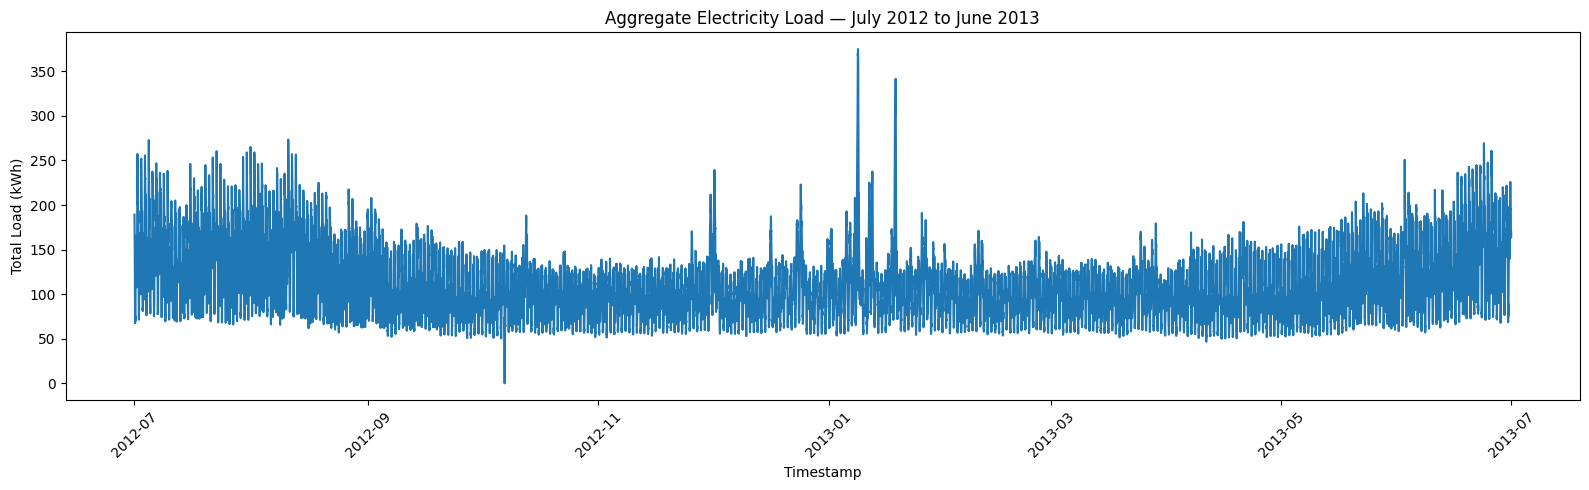

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 5))

plt.plot(
    aggregate_load["Timestamp"],
    aggregate_load["Total_Load_kWh"]
)

plt.title("Aggregate Electricity Load — July 2012 to June 2013")
plt.xlabel("Timestamp")
plt.ylabel("Total Load (kWh)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print("===== AGGREGATE LOAD STATISTICS =====")

print(
    aggregate_load["Total_Load_kWh"].describe()
)

print("\nPeak Load:")
print(
    aggregate_load.loc[
        aggregate_load["Total_Load_kWh"].idxmax()
    ]
)

print("\nMinimum Load:")
print(
    aggregate_load.loc[
        aggregate_load["Total_Load_kWh"].idxmin()
    ]
)

===== AGGREGATE LOAD STATISTICS =====
count    17520.000000
mean       109.017870
std         38.907805
min          0.000000
25%         80.098750
50%        101.377000
75%        126.913500
max        375.002000
Name: Total_Load_kWh, dtype: float64

Peak Load:
Timestamp         2013-01-08 19:30:00
Total_Load_kWh                375.002
Name: 9207, dtype: object

Minimum Load:
Timestamp         2012-10-07 02:30:00
Total_Load_kWh                    0.0
Name: 4709, dtype: object


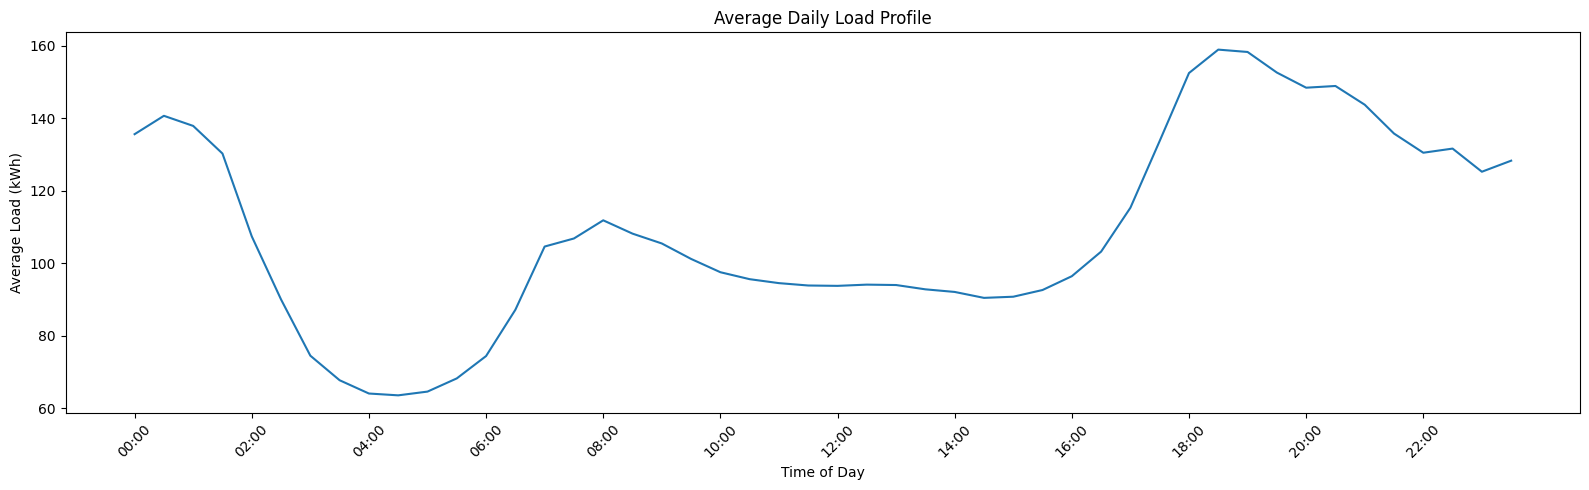

In [ ]:
aggregate_load["hour"] = aggregate_load["Timestamp"].dt.hour
aggregate_load["minute"] = aggregate_load["Timestamp"].dt.minute

aggregate_load["time_of_day"] = (
    aggregate_load["hour"].astype(str).str.zfill(2)
    + ":"
    + aggregate_load["minute"].astype(str).str.zfill(2)
)

daily_profile = (
    aggregate_load
    .groupby("time_of_day")["Total_Load_kWh"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(16, 5))

plt.plot(
    daily_profile["time_of_day"],
    daily_profile["Total_Load_kWh"]
)

plt.title("Average Daily Load Profile")
plt.xlabel("Time of Day")
plt.ylabel("Average Load (kWh)")
plt.xticks(
    range(0, 48, 4),
    daily_profile["time_of_day"].iloc[::4],
    rotation=45
)

plt.tight_layout()
plt.show()

In [ ]:
# Add calendar information
aggregate_load["day_of_week"] = aggregate_load["Timestamp"].dt.day_name()
aggregate_load["month"] = aggregate_load["Timestamp"].dt.month
aggregate_load["month_name"] = aggregate_load["Timestamp"].dt.month_name()
aggregate_load["is_weekend"] = (
    aggregate_load["Timestamp"].dt.dayofweek >= 5
)

# Average load by day of week
weekday_profile = (
    aggregate_load
    .groupby("day_of_week")["Total_Load_kWh"]
    .mean()
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
)

print("===== AVERAGE LOAD BY DAY OF WEEK =====")
display(weekday_profile)

===== AVERAGE LOAD BY DAY OF WEEK =====


,Total_Load_kWh
day_of_week,
Monday,108.168994
Tuesday,108.131533
Wednesday,104.585097
Thursday,104.528996
Friday,109.178832
Saturday,113.924389
Sunday,114.501790


In [ ]:
# Weekend vs weekday
weekend_comparison = (
    aggregate_load
    .groupby("is_weekend")["Total_Load_kWh"]
    .agg(["mean", "median", "std", "max"])
)

print("===== WEEKDAY VS WEEKEND =====")
display(weekend_comparison)

===== WEEKDAY VS WEEKEND =====


,mean,median,std,max
is_weekend,,,,
False,106.918691,98.1315,38.977096,375.002
True,114.215839,106.7605,38.246766,269.356


In [ ]:
# Monthly average load
monthly_profile = (
    aggregate_load
    .groupby(["month", "month_name"])["Total_Load_kWh"]
    .mean()
    .reset_index()
    .sort_values("month")
)

print("===== MONTHLY AVERAGE LOAD =====")
display(monthly_profile)

===== MONTHLY AVERAGE LOAD =====


,month,month_name,Total_Load_kWh
0,1,January,110.966831
1,2,February,95.557991
2,3,March,95.468067
3,4,April,95.258976
4,5,May,109.016023
5,6,June,134.735037
6,7,July,142.277788
7,8,August,130.817981
8,9,September,100.743977
9,10,October,94.691058


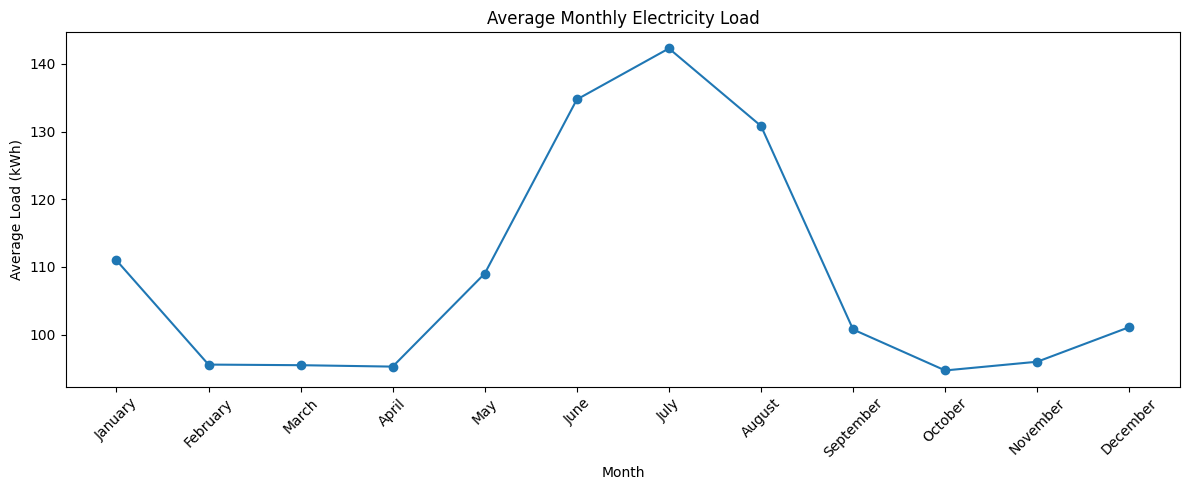

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_profile["month_name"],
    monthly_profile["Total_Load_kWh"],
    marker="o"
)

plt.title("Average Monthly Electricity Load")
plt.xlabel("Month")
plt.ylabel("Average Load (kWh)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Work on a clean copy
load_features = aggregate_load[[
    "Timestamp",
    "Total_Load_kWh"
]].copy()

# Calendar features
load_features["hour"] = load_features["Timestamp"].dt.hour
load_features["minute"] = load_features["Timestamp"].dt.minute
load_features["day_of_week"] = load_features["Timestamp"].dt.dayofweek
load_features["day_of_month"] = load_features["Timestamp"].dt.day
load_features["month"] = load_features["Timestamp"].dt.month
load_features["day_of_year"] = load_features["Timestamp"].dt.dayofyear

# Weekend
load_features["is_weekend"] = (
    load_features["day_of_week"] >= 5
).astype(int)

# Peak demand windows
load_features["morning_peak"] = (
    (load_features["hour"] >= 7) &
    (load_features["hour"] < 9)
).astype(int)

load_features["evening_peak"] = (
    (load_features["hour"] >= 18) &
    (load_features["hour"] < 21)
).astype(int)

print("Shape:", load_features.shape)

display(load_features.head(10))

Shape: (17520, 11)


,Timestamp,Total_Load_kWh,hour,minute,day_of_week,day_of_month,month,day_of_year,is_weekend,morning_peak,evening_peak
0,2012-07-01 00:00:00,189.320,0,0,6,1,7,183,1,0,0
1,2012-07-01 00:30:00,178.035,0,30,6,1,7,183,1,0,0
2,2012-07-01 01:00:00,155.212,1,0,6,1,7,183,1,0,0
3,2012-07-01 01:30:00,148.907,1,30,6,1,7,183,1,0,0
4,2012-07-01 02:00:00,123.750,2,0,6,1,7,183,1,0,0
5,2012-07-01 02:30:00,101.945,2,30,6,1,7,183,1,0,0
6,2012-07-01 03:00:00,90.629,3,0,6,1,7,183,1,0,0
7,2012-07-01 03:30:00,78.081,3,30,6,1,7,183,1,0,0
8,2012-07-01 04:00:00,67.335,4,0,6,1,7,183,1,0,0
9,2012-07-01 04:30:00,69.871,4,30,6,1,7,183,1,0,0


In [ ]:
import numpy as np

# Time-of-day cycle
total_minutes = (
    load_features["hour"] * 60
    + load_features["minute"]
)

load_features["hour_sin"] = np.sin(
    2 * np.pi * total_minutes / (24 * 60)
)

load_features["hour_cos"] = np.cos(
    2 * np.pi * total_minutes / (24 * 60)
)

# Yearly cycle
load_features["day_of_year_sin"] = np.sin(
    2 * np.pi * load_features["day_of_year"] / 365
)

load_features["day_of_year_cos"] = np.cos(
    2 * np.pi * load_features["day_of_year"] / 365
)

display(load_features.head())

,Timestamp,Total_Load_kWh,hour,minute,day_of_week,day_of_month,month,day_of_year,is_weekend,morning_peak,evening_peak,hour_sin,hour_cos,day_of_year_sin,day_of_year_cos
0,2012-07-01 00:00:00,189.320,0,0,6,1,7,183,1,0,0,0.000000,1.000000,-0.008607,-0.999963
1,2012-07-01 00:30:00,178.035,0,30,6,1,7,183,1,0,0,0.130526,0.991445,-0.008607,-0.999963
2,2012-07-01 01:00:00,155.212,1,0,6,1,7,183,1,0,0,0.258819,0.965926,-0.008607,-0.999963
3,2012-07-01 01:30:00,148.907,1,30,6,1,7,183,1,0,0,0.382683,0.923880,-0.008607,-0.999963
4,2012-07-01 02:00:00,123.750,2,0,6,1,7,183,1,0,0,0.500000,0.866025,-0.008607,-0.999963


In [ ]:
# Load lag features
load_features["lag_1"] = (
    load_features["Total_Load_kWh"].shift(1)
)

load_features["lag_2"] = (
    load_features["Total_Load_kWh"].shift(2)
)

load_features["lag_4"] = (
    load_features["Total_Load_kWh"].shift(4)
)

# Daily and multi-day lags
load_features["lag_48"] = (
    load_features["Total_Load_kWh"].shift(48)
)

load_features["lag_96"] = (
    load_features["Total_Load_kWh"].shift(96)
)

# Weekly lag
load_features["lag_336"] = (
    load_features["Total_Load_kWh"].shift(336)
)

print("Shape:", load_features.shape)

display(
    load_features[
        [
            "Timestamp",
            "Total_Load_kWh",
            "lag_1",
            "lag_2",
            "lag_4",
            "lag_48",
            "lag_96",
            "lag_336"
        ]
    ].head(10)
)

Shape: (17520, 21)


,Timestamp,Total_Load_kWh,lag_1,lag_2,lag_4,lag_48,lag_96,lag_336
0,2012-07-01 00:00:00,189.320,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-07-01 00:30:00,178.035,189.320,NaN,NaN,NaN,NaN,NaN
2,2012-07-01 01:00:00,155.212,178.035,189.320,NaN,NaN,NaN,NaN
3,2012-07-01 01:30:00,148.907,155.212,178.035,NaN,NaN,NaN,NaN
4,2012-07-01 02:00:00,123.750,148.907,155.212,189.320,NaN,NaN,NaN
5,2012-07-01 02:30:00,101.945,123.750,148.907,178.035,NaN,NaN,NaN
6,2012-07-01 03:00:00,90.629,101.945,123.750,155.212,NaN,NaN,NaN
7,2012-07-01 03:30:00,78.081,90.629,101.945,148.907,NaN,NaN,NaN
8,2012-07-01 04:00:00,67.335,78.081,90.629,123.750,NaN,NaN,NaN
9,2012-07-01 04:30:00,69.871,67.335,78.081,101.945,NaN,NaN,NaN


In [ ]:
# Past-only rolling features

past_load = load_features["Total_Load_kWh"].shift(1)

# Short-term rolling averages
load_features["rolling_mean_2"] = (
    past_load.rolling(window=2).mean()
)

load_features["rolling_mean_4"] = (
    past_load.rolling(window=4).mean()
)

# 24-hour historical statistics
load_features["rolling_mean_48"] = (
    past_load.rolling(window=48).mean()
)

load_features["rolling_std_48"] = (
    past_load.rolling(window=48).std()
)

print("Shape:", load_features.shape)

display(
    load_features[
        [
            "Timestamp",
            "Total_Load_kWh",
            "rolling_mean_2",
            "rolling_mean_4",
            "rolling_mean_48",
            "rolling_std_48"
        ]
    ].head(55)
)

Shape: (17520, 25)


,Timestamp,Total_Load_kWh,rolling_mean_2,rolling_mean_4,rolling_mean_48,rolling_std_48
0,2012-07-01 00:00:00,189.320,NaN,NaN,NaN,NaN
1,2012-07-01 00:30:00,178.035,NaN,NaN,NaN,NaN
2,2012-07-01 01:00:00,155.212,183.6775,NaN,NaN,NaN
3,2012-07-01 01:30:00,148.907,166.6235,NaN,NaN,NaN
4,2012-07-01 02:00:00,123.750,152.0595,167.86850,NaN,NaN
5,2012-07-01 02:30:00,101.945,136.3285,151.47600,NaN,NaN
6,2012-07-01 03:00:00,90.629,112.8475,132.45350,NaN,NaN
7,2012-07-01 03:30:00,78.081,96.2870,116.30775,NaN,NaN
8,2012-07-01 04:00:00,67.335,84.3550,98.60125,NaN,NaN
9,2012-07-01 04:30:00,69.871,72.7080,84.49750,NaN,NaN


In [ ]:
# Create next 30-minute load target
load_features["target"] = (
    load_features["Total_Load_kWh"].shift(-1)
)

print("Before removing NaNs:")
print("Shape:", load_features.shape)

display(
    load_features[
        [
            "Timestamp",
            "Total_Load_kWh",
            "lag_1",
            "lag_48",
            "lag_336",
            "rolling_mean_48",
            "target"
        ]
    ].head(10)
)

Before removing NaNs:
Shape: (17520, 26)


,Timestamp,Total_Load_kWh,lag_1,lag_48,lag_336,rolling_mean_48,target
0,2012-07-01 00:00:00,189.320,NaN,NaN,NaN,NaN,178.035
1,2012-07-01 00:30:00,178.035,189.320,NaN,NaN,NaN,155.212
2,2012-07-01 01:00:00,155.212,178.035,NaN,NaN,NaN,148.907
3,2012-07-01 01:30:00,148.907,155.212,NaN,NaN,NaN,123.750
4,2012-07-01 02:00:00,123.750,148.907,NaN,NaN,NaN,101.945
5,2012-07-01 02:30:00,101.945,123.750,NaN,NaN,NaN,90.629
6,2012-07-01 03:00:00,90.629,101.945,NaN,NaN,NaN,78.081
7,2012-07-01 03:30:00,78.081,90.629,NaN,NaN,NaN,67.335
8,2012-07-01 04:00:00,67.335,78.081,NaN,NaN,NaN,69.871
9,2012-07-01 04:30:00,69.871,67.335,NaN,NaN,NaN,74.400


In [ ]:
# Remove rows where historical features or target are unavailable
load_features_clean = load_features.dropna().reset_index(drop=True)

print("Final modelling dataset shape:", load_features_clean.shape)

print("\nMissing values:")
print(load_features_clean.isna().sum().sum())

print("\nDate range:")
print(
    load_features_clean["Timestamp"].min(),
    "→",
    load_features_clean["Timestamp"].max()
)

Final modelling dataset shape: (17183, 26)

Missing values:
0

Date range:
2012-07-08 00:00:00 → 2013-06-30 23:00:00


In [ ]:
# Verify target alignment
check = load_features_clean[
    ["Timestamp", "Total_Load_kWh", "target"]
].head(10).copy()

check["actual_next_load"] = (
    load_features_clean["Total_Load_kWh"].shift(-1).head(10).values
)

display(check)

,Timestamp,Total_Load_kWh,target,actual_next_load
0,2012-07-08 00:00:00,178.265,213.914,213.914
1,2012-07-08 00:30:00,213.914,184.223,184.223
2,2012-07-08 01:00:00,184.223,171.707,171.707
3,2012-07-08 01:30:00,171.707,142.249,142.249
4,2012-07-08 02:00:00,142.249,118.174,118.174
5,2012-07-08 02:30:00,118.174,103.114,103.114
6,2012-07-08 03:00:00,103.114,86.642,86.642
7,2012-07-08 03:30:00,86.642,76.951,76.951
8,2012-07-08 04:00:00,76.951,74.200,74.200
9,2012-07-08 04:30:00,74.200,77.188,77.188


In [ ]:
time_diff = (
    load_features_clean["Timestamp"].shift(-1)
    - load_features_clean["Timestamp"]
)

print(
    "Unique timestamp gaps:",
    time_diff.dropna().unique()
)

Unique timestamp gaps: <TimedeltaArray>
['0 days 00:30:00']
Length: 1, dtype: timedelta64[ns]


In [ ]:
load_features_clean.to_csv(
    "load_forecasting_processed.csv",
    index=False
)

print("Saved: load_forecasting_processed.csv")

Saved: load_forecasting_processed.csv


In [ ]:
# Unique postcodes in the original dataset
postcode_info = (
    df[["Customer", "Postcode"]]
    .drop_duplicates()
    .sort_values("Postcode")
)

print("Number of unique postcodes:",
      postcode_info["Postcode"].nunique())

print("\nFirst 30 postcodes:")
print(postcode_info.head(30))

print("\nCustomers per postcode:")
print(
    postcode_info["Postcode"]
    .value_counts()
    .sort_index()
)

Number of unique postcodes: 100

First 30 postcodes:
        Customer  Postcode
103670       116      2008
42827         48      2010
170713       192      2018
124110       139      2018
40637         45      2021
27862         31      2025
244698       275      2026
10707         11      2026
55602         62      2029
70867         78      2031
182028       205      2034
224323       251      2037
195898       220      2037
71597         79      2039
101480       113      2041
28592         32      2041
147046       164      2044
257043       288      2044
114985       128      2044
115715       129      2046
166756       187      2047
89070         99      2048
35892         40      2048
153981       172      2066
142360       159      2066
86150         96      2066
229068       257      2066
148506       166      2074
231623       260      2074
226878       254      2074

Customers per postcode:
Postcode
2008    1
2010    1
2018    2
2021    1
2025    1
       ..
2321    1
2324  

In [ ]:
print("\nPostcode range:")
print(postcode_info["Postcode"].min(),
      "→",
      postcode_info["Postcode"].max())


Postcode range:
2008 → 2330


Weather forecast


In [ ]:
import pandas as pd

postcode_url = (
    "https://raw.githubusercontent.com/schappim/"
    "australian-postcodes/master/australian-postcodes.csv"
)

postcode_geo = pd.read_csv(
    postcode_url,
    dtype={"Postcode": str}
)

print(postcode_geo.shape)
print(postcode_geo.columns.tolist())
print(postcode_geo.head())

(16511, 6)
['Postcode', 'Suburb', 'State', 'Lat', 'Lon', 'Category']
  Postcode                          Suburb State    Lat     Lon  \
0     2601                           ACTON   ACT -35.28  149.11   
1     2602                         AINSLIE   ACT -35.26  149.15   
2     2914                          AMAROO   ACT -35.17  149.13   
3     2614                          ARANDA   ACT -35.26  149.08   
4     0200  AUSTRALIAN NATIONAL UNIVERSITY   ACT -35.28  149.12   

            Category  
0      Delivery Area  
1      Delivery Area  
2      Delivery Area  
3      Delivery Area  
4  Post Office Boxes  


In [ ]:
# Our postcodes
our_postcodes = (
    df["Postcode"]
    .astype(str)
    .str.zfill(4)
    .unique()
)

print("Our postcodes:", len(our_postcodes))

# Keep only postcodes used by our dataset
weather_locations = postcode_geo[
    postcode_geo["Postcode"].isin(our_postcodes)
].copy()

print("Matched rows:", len(weather_locations))
print(
    "Matched unique postcodes:",
    weather_locations["Postcode"].nunique()
)

Our postcodes: 100
Matched rows: 610
Matched unique postcodes: 100


In [ ]:
print("Missing latitude:",
      weather_locations["Lat"].isna().sum())

print("Missing longitude:",
      weather_locations["Lon"].isna().sum())

print(
    weather_locations[
        ["Postcode", "Suburb", "State", "Lat", "Lon"]
    ].head(30)
)

Missing latitude: 12
Missing longitude: 12
    Postcode               Suburb State    Lat     Lon
153     2046           ABBOTSFORD   NSW -33.85  151.13
156     2325             ABERDARE   NSW -32.84  151.38
159     2320         ABERGLASSLYN   NSW -32.69  151.53
160     2326             ABERMAIN   NSW -32.81  151.43
161     2325            ABERNETHY   NSW -32.84  151.38
166     2289            ADAMSTOWN   NSW -32.93  151.73
167     2289    ADAMSTOWN HEIGHTS   NSW -32.93  151.73
185     2259               ALISON   NSW -33.27  151.40
187     2100     ALLAMBIE HEIGHTS   NSW -33.77  151.25
188     2320            ALLANDALE   NSW -32.69  151.53
189     2218              ALLAWAH   NSW -33.97  151.11
204     2320              ANAMBAH   NSW -32.69  151.53
218     2330       APPLETREE FLAT   NSW -32.51  150.86
224     2159              ARCADIA   NSW -33.62  151.05
225     2283         ARCADIA VALE   NSW -33.06  151.58
230     2284             ARGENTON   NSW -32.93  151.63
240     2205          

In [ ]:
# Keep one coordinate record per postcode
postcode_coords = (
    weather_locations[
        ["Postcode", "Suburb", "State", "Lat", "Lon"]
    ]
    .drop_duplicates(subset=["Postcode"])
    .copy()
)

print("Unique postcode rows:", len(postcode_coords))

print("\nMissing coordinates:")
print(
    postcode_coords[
        postcode_coords["Lat"].isna() |
        postcode_coords["Lon"].isna()
    ]
)

Unique postcode rows: 100

Missing coordinates:
Empty DataFrame
Columns: [Postcode, Suburb, State, Lat, Lon]
Index: []


In [ ]:
print("\nNumber of postcodes with missing coordinates:",
      postcode_coords[
          postcode_coords["Lat"].isna() |
          postcode_coords["Lon"].isna()
      ].shape[0])


Number of postcodes with missing coordinates: 0


In [ ]:
print("\nCoordinate coverage:")
print(
    postcode_coords[
        ["Postcode", "Lat", "Lon"]
    ].sort_values("Postcode").to_string(index=False)
)


Coordinate coverage:
Postcode    Lat    Lon
    2008 -33.89 151.20
    2010 -33.88 151.22
    2018 -33.93 151.21
    2021 -33.89 151.22
    2025 -33.89 151.24
    2026 -33.89 151.26
    2029 -33.87 151.28
    2031 -33.91 151.26
    2034 -33.92 151.25
    2037 -33.88 151.18
    2039 -33.86 151.17
    2041 -33.86 151.18
    2044 -33.91 151.18
    2046 -33.85 151.13
    2047 -33.85 151.15
    2048 -33.90 151.17
    2066 -33.81 151.17
    2074 -33.71 151.15
    2076 -33.72 151.10
    2077 -33.69 151.11
    2079 -33.66 151.12
    2081 -33.62 151.15
    2082 -33.61 151.14
    2084 -33.62 151.20
    2085 -33.74 151.21
    2086 -33.75 151.23
    2087 -33.76 151.21
    2088 -33.83 151.24
    2092 -33.80 151.25
    2093 -33.79 151.26
    2096 -33.77 151.29
    2099 -33.74 151.28
    2100 -33.77 151.25
    2111 -33.82 151.14
    2119 -33.75 151.06
    2120 -33.74 151.07
    2126 -33.72 151.04
    2134 -33.88 151.10
    2135 -33.87 151.09
    2137 -33.84 151.11
    2154 -33.73 151.01
    2159 -33

In [ ]:
import requests
import pandas as pd

# Make sure postcode is a string
postcode_coords["Postcode"] = (
    postcode_coords["Postcode"]
    .astype(str)
    .str.zfill(4)
)

# Coordinates
latitudes = ",".join(
    postcode_coords["Lat"].astype(str)
)

longitudes = ",".join(
    postcode_coords["Lon"].astype(str)
)

url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": latitudes,
    "longitude": longitudes,
    "start_date": "2012-07-01",
    "end_date": "2013-06-30",
    "hourly": ",".join([
        "temperature_2m",
        "relative_humidity_2m",
        "cloud_cover",
        "precipitation",
        "wind_speed_10m"
    ]),
    "timezone": "Australia/Sydney",
    "models": "era5"
}

response = requests.get(
    url,
    params=params,
    timeout=120
)

print("Status code:", response.status_code)

weather_data = response.json()

print(type(weather_data))

Status code: 200
<class 'list'>


In [ ]:
if isinstance(weather_data, list):

    print("Number of weather locations:",
          len(weather_data))

    print("\nFirst location keys:")
    print(weather_data[0].keys())

else:

    print("Response keys:")
    print(weather_data.keys())

Number of weather locations: 100

First location keys:
dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'hourly_units', 'hourly'])


In [ ]:
weather_frames = []

for i, location in enumerate(weather_data):

    hourly = pd.DataFrame(location["hourly"])

    # Add postcode and coordinates
    hourly["Postcode"] = postcode_coords.iloc[i]["Postcode"]
    hourly["Latitude"] = location["latitude"]
    hourly["Longitude"] = location["longitude"]

    weather_frames.append(hourly)


weather_df = pd.concat(
    weather_frames,
    ignore_index=True
)

print("Weather dataframe shape:", weather_df.shape)
print("\nColumns:")
print(weather_df.columns.tolist())

print("\nFirst 5 rows:")
print(weather_df.head())

Weather dataframe shape: (876000, 9)

Columns:
['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'precipitation', 'wind_speed_10m', 'Postcode', 'Latitude', 'Longitude']

First 5 rows:
               time  temperature_2m  relative_humidity_2m  cloud_cover  \
0  2012-07-01T00:00             7.6                    86           50   
1  2012-07-01T01:00             7.7                    84           43   
2  2012-07-01T02:00             6.6                    88           30   
3  2012-07-01T03:00             6.2                    89           30   
4  2012-07-01T04:00             5.9                    90           11   

   precipitation  wind_speed_10m Postcode  Latitude  Longitude  
0            0.0             6.5     2046    -33.75      151.0  
1            0.0             6.9     2046    -33.75      151.0  
2            0.0             7.2     2046    -33.75      151.0  
3            0.0             7.3     2046    -33.75      151.0  
4            0.0             7

In [ ]:
print("\nUnique postcodes:",
      weather_df["Postcode"].nunique())

print("\nTimestamp range:")
print(weather_df["time"].min(),
      "→",
      weather_df["time"].max())


Unique postcodes: 100

Timestamp range:
2012-07-01T00:00 → 2013-06-30T23:00


In [ ]:
weather_df["time"] = pd.to_datetime(
    weather_df["time"]
)

print(weather_df["time"].dtype)

datetime64[ns]


In [ ]:
# Make a clean copy
weather_hourly = weather_df.copy()

weather_hourly["time"] = pd.to_datetime(
    weather_hourly["time"]
)

# Keep only the columns we need
weather_hourly = weather_hourly[
    [
        "Postcode",
        "time",
        "temperature_2m",
        "relative_humidity_2m",
        "cloud_cover",
        "precipitation",
        "wind_speed_10m"
    ]
].copy()

print(weather_hourly.shape)
print(weather_hourly.head())

(876000, 7)
  Postcode                time  temperature_2m  relative_humidity_2m  \
0     2046 2012-07-01 00:00:00             7.6                    86   
1     2046 2012-07-01 01:00:00             7.7                    84   
2     2046 2012-07-01 02:00:00             6.6                    88   
3     2046 2012-07-01 03:00:00             6.2                    89   
4     2046 2012-07-01 04:00:00             5.9                    90   

   cloud_cover  precipitation  wind_speed_10m  
0           50            0.0             6.5  
1           43            0.0             6.9  
2           30            0.0             7.2  
3           30            0.0             7.3  
4           11            0.0             7.2  


In [ ]:
# Create 30-minute timestamps for the entire period
time_30min = pd.date_range(
    start="2012-07-01 00:00:00",
    end="2013-06-30 23:30:00",
    freq="30min"
)

print("Number of 30-min timestamps:", len(time_30min))

Number of 30-min timestamps: 17520


In [ ]:
weather_hourly = weather_df.copy()

weather_hourly["time"] = pd.to_datetime(
    weather_hourly["time"]
)

weather_hourly = weather_hourly[
    [
        "Postcode",
        "time",
        "temperature_2m",
        "relative_humidity_2m",
        "cloud_cover",
        "precipitation",
        "wind_speed_10m"
    ]
].copy()

print(weather_hourly.shape)
print(weather_hourly.head())
print(weather_hourly.index)

(876000, 7)
  Postcode                time  temperature_2m  relative_humidity_2m  \
0     2046 2012-07-01 00:00:00             7.6                    86   
1     2046 2012-07-01 01:00:00             7.7                    84   
2     2046 2012-07-01 02:00:00             6.6                    88   
3     2046 2012-07-01 03:00:00             6.2                    89   
4     2046 2012-07-01 04:00:00             5.9                    90   

   cloud_cover  precipitation  wind_speed_10m  
0           50            0.0             6.5  
1           43            0.0             6.9  
2           30            0.0             7.2  
3           30            0.0             7.3  
4           11            0.0             7.2  
RangeIndex(start=0, stop=876000, step=1)


In [ ]:
time_30min = pd.date_range(
    start="2012-07-01 00:00:00",
    end="2013-06-30 23:30:00",
    freq="30min"
)

print("Number of timestamps:", len(time_30min))
print(time_30min[:5])
print(time_30min[-5:])

Number of timestamps: 17520
DatetimeIndex(['2012-07-01 00:00:00', '2012-07-01 00:30:00',
               '2012-07-01 01:00:00', '2012-07-01 01:30:00',
               '2012-07-01 02:00:00'],
              dtype='datetime64[ns]', freq='30min')
DatetimeIndex(['2013-06-30 21:30:00', '2013-06-30 22:00:00',
               '2013-06-30 22:30:00', '2013-06-30 23:00:00',
               '2013-06-30 23:30:00'],
              dtype='datetime64[ns]', freq='30min')


In [ ]:
postcode_list = weather_hourly["Postcode"].unique()

weather_30min = pd.MultiIndex.from_product(
    [postcode_list, time_30min],
    names=["Postcode", "time"]
).to_frame(index=False)

print("Shape:", weather_30min.shape)
print(weather_30min.head())
print(weather_30min.tail())

Shape: (1752000, 2)
  Postcode                time
0     2046 2012-07-01 00:00:00
1     2046 2012-07-01 00:30:00
2     2046 2012-07-01 01:00:00
3     2046 2012-07-01 01:30:00
4     2046 2012-07-01 02:00:00
        Postcode                time
1751995     2025 2013-06-30 21:30:00
1751996     2025 2013-06-30 22:00:00
1751997     2025 2013-06-30 22:30:00
1751998     2025 2013-06-30 23:00:00
1751999     2025 2013-06-30 23:30:00


In [ ]:
weather_30min = weather_30min.merge(
    weather_hourly,
    on=["Postcode", "time"],
    how="left"
)

print("Shape:", weather_30min.shape)
print(weather_30min.head())
print(weather_30min.isna().sum())

Shape: (1752000, 7)
  Postcode                time  temperature_2m  relative_humidity_2m  \
0     2046 2012-07-01 00:00:00             7.6                  86.0   
1     2046 2012-07-01 00:30:00             NaN                   NaN   
2     2046 2012-07-01 01:00:00             7.7                  84.0   
3     2046 2012-07-01 01:30:00             NaN                   NaN   
4     2046 2012-07-01 02:00:00             6.6                  88.0   

   cloud_cover  precipitation  wind_speed_10m  
0         50.0            0.0             6.5  
1          NaN            NaN             NaN  
2         43.0            0.0             6.9  
3          NaN            NaN             NaN  
4         30.0            0.0             7.2  
Postcode                     0
time                         0
temperature_2m          876000
relative_humidity_2m    876000
cloud_cover             876000
precipitation           876000
wind_speed_10m          876000
dtype: int64


In [ ]:
weather_cols = [
    "temperature_2m",
    "relative_humidity_2m",
    "cloud_cover",
    "precipitation",
    "wind_speed_10m"
]

weather_30min[weather_cols] = (
    weather_30min
    .groupby("Postcode")[weather_cols]
    .ffill()
)

print("Missing values after forward-fill:")
print(weather_30min[weather_cols].isna().sum())

print("\nShape:", weather_30min.shape)
print(weather_30min.head(6))

Missing values after forward-fill:
temperature_2m          0
relative_humidity_2m    0
cloud_cover             0
precipitation           0
wind_speed_10m          0
dtype: int64

Shape: (1752000, 7)
  Postcode                time  temperature_2m  relative_humidity_2m  \
0     2046 2012-07-01 00:00:00             7.6                  86.0   
1     2046 2012-07-01 00:30:00             7.6                  86.0   
2     2046 2012-07-01 01:00:00             7.7                  84.0   
3     2046 2012-07-01 01:30:00             7.7                  84.0   
4     2046 2012-07-01 02:00:00             6.6                  88.0   
5     2046 2012-07-01 02:30:00             6.6                  88.0   

   cloud_cover  precipitation  wind_speed_10m  
0         50.0            0.0             6.5  
1         50.0            0.0             6.5  
2         43.0            0.0             6.9  
3         43.0            0.0             6.9  
4         30.0            0.0             7.2  
5       

In [ ]:
customer_postcode = (
    df[df["Customer"] != 2][["Customer", "Postcode"]]
    .drop_duplicates()
)

postcode_weights = (
    customer_postcode
    .groupby("Postcode")
    .size()
    .reset_index(name="Customer_Count")
)

postcode_weights["Weight"] = (
    postcode_weights["Customer_Count"]
    / postcode_weights["Customer_Count"].sum()
)

print("Total customers:", postcode_weights["Customer_Count"].sum())
print("Unique postcodes:", postcode_weights["Postcode"].nunique())
print(postcode_weights.head(10))
print("\nWeight sum:", postcode_weights["Weight"].sum())

Total customers: 299
Unique postcodes: 100
   Postcode  Customer_Count    Weight
0      2008               1  0.003344
1      2010               1  0.003344
2      2018               2  0.006689
3      2021               1  0.003344
4      2025               1  0.003344
5      2026               2  0.006689
6      2029               1  0.003344
7      2031               1  0.003344
8      2034               1  0.003344
9      2037               2  0.006689

Weight sum: 0.9999999999999999


In [ ]:
weather_30min["Postcode"] = weather_30min["Postcode"].astype(str)
postcode_weights["Postcode"] = postcode_weights["Postcode"].astype(str)

print("weather_30min:", weather_30min["Postcode"].dtype)
print("postcode_weights:", postcode_weights["Postcode"].dtype)

weather_30min: object
postcode_weights: object


In [ ]:
weather_weighted = weather_30min.merge(
    postcode_weights[["Postcode", "Weight"]],
    on="Postcode",
    how="left"
)

print("Shape:", weather_weighted.shape)
print(weather_weighted.head())
print("\nMissing weights:", weather_weighted["Weight"].isna().sum())

Shape: (1752000, 8)
  Postcode                time  temperature_2m  relative_humidity_2m  \
0     2046 2012-07-01 00:00:00             7.6                  86.0   
1     2046 2012-07-01 00:30:00             7.6                  86.0   
2     2046 2012-07-01 01:00:00             7.7                  84.0   
3     2046 2012-07-01 01:30:00             7.7                  84.0   
4     2046 2012-07-01 02:00:00             6.6                  88.0   

   cloud_cover  precipitation  wind_speed_10m    Weight  
0         50.0            0.0             6.5  0.003344  
1         50.0            0.0             6.5  0.003344  
2         43.0            0.0             6.9  0.003344  
3         43.0            0.0             6.9  0.003344  
4         30.0            0.0             7.2  0.003344  

Missing weights: 0


In [ ]:
weather_cols = [
    "temperature_2m",
    "relative_humidity_2m",
    "cloud_cover",
    "precipitation",
    "wind_speed_10m"
]

for col in weather_cols:
    weather_weighted[col] = weather_weighted[col] * weather_weighted["Weight"]

grid_weather = (
    weather_weighted
    .groupby("time")[weather_cols]
    .sum()
    .reset_index()
)

print("Shape:", grid_weather.shape)
print(grid_weather.head())
print("\nMissing values:")
print(grid_weather.isna().sum())

Shape: (17520, 6)
                 time  temperature_2m  relative_humidity_2m  cloud_cover  \
0 2012-07-01 00:00:00       10.010368             79.585284    45.538462   
1 2012-07-01 00:30:00       10.010368             79.585284    45.538462   
2 2012-07-01 01:00:00        9.968896             79.745819    42.133779   
3 2012-07-01 01:30:00        9.968896             79.745819    42.133779   
4 2012-07-01 02:00:00        9.181271             82.548495    36.826087   

   precipitation  wind_speed_10m  
0            0.0        7.482609  
1            0.0        7.482609  
2            0.0        7.298662  
3            0.0        7.298662  
4            0.0        7.474247  

Missing values:
time                    0
temperature_2m          0
relative_humidity_2m    0
cloud_cover             0
precipitation           0
wind_speed_10m          0
dtype: int64


In [ ]:
load_weather = aggregate_load.merge(
    grid_weather,
    left_on="Timestamp",
    right_on="time",
    how="left"
).drop(columns=["time"])

print("Shape:", load_weather.shape)
print(load_weather.head())
print("\nMissing values:")
print(load_weather.isna().sum())

Shape: (17520, 14)
            Timestamp  Total_Load_kWh  hour  minute time_of_day day_of_week  \
0 2012-07-01 00:00:00         189.320     0       0       00:00      Sunday   
1 2012-07-01 00:30:00         178.035     0      30       00:30      Sunday   
2 2012-07-01 01:00:00         155.212     1       0       01:00      Sunday   
3 2012-07-01 01:30:00         148.907     1      30       01:30      Sunday   
4 2012-07-01 02:00:00         123.750     2       0       02:00      Sunday   

   month month_name  is_weekend  temperature_2m  relative_humidity_2m  \
0      7       July        True       10.010368             79.585284   
1      7       July        True       10.010368             79.585284   
2      7       July        True        9.968896             79.745819   
3      7       July        True        9.968896             79.745819   
4      7       July        True        9.181271             82.548495   

   cloud_cover  precipitation  wind_speed_10m  
0    45.538462     

In [ ]:
weather_features = load_weather.copy()

# Past load features
weather_features["lag_1"] = weather_features["Total_Load_kWh"].shift(1)
weather_features["lag_2"] = weather_features["Total_Load_kWh"].shift(2)
weather_features["lag_4"] = weather_features["Total_Load_kWh"].shift(4)
weather_features["lag_48"] = weather_features["Total_Load_kWh"].shift(48)
weather_features["lag_96"] = weather_features["Total_Load_kWh"].shift(96)
weather_features["lag_336"] = weather_features["Total_Load_kWh"].shift(336)

# Past-only rolling features
past_load = weather_features["Total_Load_kWh"].shift(1)

weather_features["rolling_mean_2"] = past_load.rolling(2).mean()
weather_features["rolling_mean_4"] = past_load.rolling(4).mean()
weather_features["rolling_mean_48"] = past_load.rolling(48).mean()
weather_features["rolling_std_48"] = past_load.rolling(48).std()

# Next 30-minute load = prediction target
weather_features["target"] = (
    weather_features["Total_Load_kWh"].shift(-1)
)

print("Shape:", weather_features.shape)
print(weather_features.tail())

Shape: (17520, 25)
                Timestamp  Total_Load_kWh  hour  minute time_of_day  \
17515 2013-06-30 21:30:00         165.139    21      30       21:30   
17516 2013-06-30 22:00:00         170.895    22       0       22:00   
17517 2013-06-30 22:30:00         169.309    22      30       22:30   
17518 2013-06-30 23:00:00         163.463    23       0       23:00   
17519 2013-06-30 23:30:00         169.782    23      30       23:30   

      day_of_week  month month_name  is_weekend  temperature_2m  ...    lag_2  \
17515      Sunday      6       June        True       12.859866  ...  190.454   
17516      Sunday      6       June        True       12.926087  ...  185.096   
17517      Sunday      6       June        True       12.926087  ...  165.139   
17518      Sunday      6       June        True       12.142475  ...  170.895   
17519      Sunday      6       June        True       12.142475  ...  169.309   

         lag_4   lag_48   lag_96  lag_336  rolling_mean_2  rolling_

In [ ]:
weather_features_clean = (
    weather_features
    .dropna()
    .reset_index(drop=True)
)

print("Shape:", weather_features_clean.shape)
print("Missing values:", weather_features_clean.isna().sum().sum())
print("Start:", weather_features_clean["Timestamp"].min())
print("End:", weather_features_clean["Timestamp"].max())

Shape: (17183, 25)
Missing values: 0
Start: 2012-07-08 00:00:00
End: 2013-06-30 23:00:00


In [ ]:
target_col = "target"

exclude_cols = [
    "Timestamp",
    "Total_Load_kWh",
    "time_of_day",
    "day_of_week",
    "month_name",
    target_col
]

feature_cols_weather = [
    col for col in weather_features_clean.columns
    if col not in exclude_cols
]

X_weather = weather_features_clean[feature_cols_weather]
y_weather = weather_features_clean[target_col]

print("Number of features:", len(feature_cols_weather))
print("\nFeatures:")
print(feature_cols_weather)
print("\nX shape:", X_weather.shape)
print("y shape:", y_weather.shape)

Number of features: 19

Features:
['hour', 'minute', 'month', 'is_weekend', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'precipitation', 'wind_speed_10m', 'lag_1', 'lag_2', 'lag_4', 'lag_48', 'lag_96', 'lag_336', 'rolling_mean_2', 'rolling_mean_4', 'rolling_mean_48', 'rolling_std_48']

X shape: (17183, 19)
y shape: (17183,)


In [ ]:
n = len(weather_features_clean)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train_weather = X_weather.iloc[:train_end]
y_train_weather = y_weather.iloc[:train_end]

X_val_weather = X_weather.iloc[train_end:val_end]
y_val_weather = y_weather.iloc[train_end:val_end]

X_test_weather = X_weather.iloc[val_end:]
y_test_weather = y_weather.iloc[val_end:]

print("Train:", X_train_weather.shape, y_train_weather.shape)
print("Validation:", X_val_weather.shape, y_val_weather.shape)
print("Test:", X_test_weather.shape, y_test_weather.shape)

print("\nTrain period:",
      weather_features_clean["Timestamp"].iloc[0],
      "→",
      weather_features_clean["Timestamp"].iloc[train_end - 1])

print("Validation period:",
      weather_features_clean["Timestamp"].iloc[train_end],
      "→",
      weather_features_clean["Timestamp"].iloc[val_end - 1])

print("Test period:",
      weather_features_clean["Timestamp"].iloc[val_end],
      "→",
      weather_features_clean["Timestamp"].iloc[-1])

Train: (12028, 19) (12028,)
Validation: (2577, 19) (2577,)
Test: (2578, 19) (2578,)

Train period: 2012-07-08 00:00:00 → 2013-03-15 13:30:00
Validation period: 2013-03-15 14:00:00 → 2013-05-08 06:00:00
Test period: 2013-05-08 06:30:00 → 2013-06-30 23:00:00


In [ ]:
from xgboost import XGBRegressor

weather_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

weather_model.fit(
    X_train_weather,
    y_train_weather,
    eval_set=[(X_val_weather, y_val_weather)],
    verbose=False
)

print("Weather-enhanced XGBoost training completed.")

Weather-enhanced XGBoost training completed.


In [ ]:
import os

os.makedirs("/content/weather_datasets", exist_ok=True)

grid_weather.to_csv(
    "/content/weather_datasets/grid_weather_30min.csv",
    index=False
)

load_weather.to_csv(
    "/content/weather_datasets/load_weather_combined.csv",
    index=False
)

weather_features_clean.to_csv(
    "/content/weather_datasets/load_weather_features.csv",
    index=False
)

print("Datasets saved successfully.")

print("\nFiles:")
print(os.listdir("/content/weather_datasets"))

Datasets saved successfully.

Files:
['load_weather_combined.csv', 'grid_weather_30min.csv', 'load_weather_features.csv']
